## Sampling
#### Definition

Sampling is the process of selecting a smaller group of people, objects, or data points from a larger population to study and understand the population.

Important Terms
- Population – The complete group we want to study.
- Sample – A smaller group selected from the population.
- Sampling – The process of selecting the sample.

### Example
Suppose a college has 5,000 students and we want to know their average satisfaction with the college.
Instead of asking all 5,000 students, we select 500 students and ask them.



In [1]:
import numpy as np

# Population
population = np.arange(1, 5001)

# Select a sample of 500 students
sample = np.random.choice(population, size=500, replace=False)

print("Population size:", len(population))
print("Sample size:", len(sample))
print("First 10 sampled students:", sample[:10])

Population size: 5000
Sample size: 500
First 10 sampled students: [ 833 2145 2800 3120 1084  437 1813 2164 2233  468]


## Random Sampling
Definition

Random Sampling is a sampling method where every member of the population has an equal or known chance of being selected.
### Example
Imagine a company has 1,000 employees and wants to survey 100 employees.
Using random sampling, the company randomly selects 100 employees.
Every employee has an equal opportunity to be selected


In [2]:
import numpy as np

employees = np.arange(1, 1001)

sample = np.random.choice(
    employees,
    size=100,
    replace=False
)

print("Number of employees:", len(employees))
print("Number selected:", len(sample))
print("Selected employees:", sample[:10])

Number of employees: 1000
Number selected: 100
Selected employees: [605 248 953 551 660  11 657 931 726 947]


## Stratified Sampling
Stratified Sampling divides the population into different groups called strata and then selects samples from each group.
### Example
Suppose a company has:

Male employees   → 600

Female employees → 400

If we want a sample of 100 employees, we can select:

Male   → 60

Female → 40


In [3]:
import pandas as pd

data = pd.DataFrame({
    "Employee": range(1, 11),
    "Department": [
        "IT", "IT", "IT",
        "HR", "HR",
        "Finance", "Finance",
        "Sales", "Sales", "Sales"
    ]
})

# Select samples from each department
sample = data.groupby("Department").sample(
    n=1,
    random_state=42
)

print(sample)

   Employee Department
6         7    Finance
3         4         HR
1         2         IT
7         8      Sales


## Cluster Sampling
Cluster Sampling divides the population into groups called clusters, then randomly selects some complete clusters.
### Example
Suppose a company has offices in 10 cities.
Instead of surveying employees from all 10 cities, we randomly select 3 cities:
- Chennai
- Bangalore
- Mumbai

In [5]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    "Employee_ID": range(1, 13),
    "City": [
        "Chennai", "Chennai", "Chennai",
        "Bangalore", "Bangalore", "Bangalore",
        "Mumbai", "Mumbai", "Mumbai",
        "Delhi", "Delhi", "Delhi"
    ]
})

# Select two cities randomly
selected_cities = np.random.choice(
    data["City"].unique(),
    size=2,
    replace=False
)

cluster_sample = data[
    data["City"].isin(selected_cities)
]

print("Selected clusters:", selected_cities)
print("\nCluster Sample:")
print(cluster_sample)

Selected clusters: ['Bangalore' 'Delhi']

Cluster Sample:
    Employee_ID       City
3             4  Bangalore
4             5  Bangalore
5             6  Bangalore
9            10      Delhi
10           11      Delhi
11           12      Delhi


## Systematic Sampling
Systematic Sampling selects members from a population using a fixed interval.
### Example:
Suppose we have 1,000 customers and need a sample of 100 customers.

Calculate:

$$ k=\frac{N}{n} $$

Where:

\(N\) = population size
\(n\) = sample size

So:

$$ k=\frac{1000}{100}=10 $$

We can randomly choose a starting customer, say customer 5.

In [6]:
import numpy as np

customers = np.arange(1, 1001)

# Sampling interval
k = 10

# Random starting point
start = np.random.randint(0, k)

# Select every 10th customer
sample = customers[start::k]

print("Selected customers:")
print(sample[:20])

Selected customers:
[  6  16  26  36  46  56  66  76  86  96 106 116 126 136 146 156 166 176
 186 196]


## Sampling Bias
Sampling Bias occurs when the selected sample does not properly represent the population because some members have a higher or lower chance of being selected.
### Example
Suppose a company wants to know whether all employees are happy with their salaries.
They survey only senior managers.
Senior managers may have different salaries and experiences compared with junior employees.
Therefore, the sample does not represent the whole employee population.
This can create sampling bias.


In [7]:
import numpy as np

# Population: 800 junior employees and 200 senior employees
population = np.array(
    ["Junior"] * 800 + ["Senior"] * 200
)

# Biased sample: selecting only senior employees
biased_sample = np.array(["Senior"] * 100)

print("Population:")
print("Junior:", np.sum(population == "Junior"))
print("Senior:", np.sum(population == "Senior"))

print("\nBiased Sample:")
print("Junior:", np.sum(biased_sample == "Junior"))
print("Senior:", np.sum(biased_sample == "Senior"))

Population:
Junior: 800
Senior: 200

Biased Sample:
Junior: 0
Senior: 100


## Sampling Error
Sampling Error is the difference between a value calculated from a sample and the actual value of the population.
### Formula
For the mean:

Sampling Error = Sample Mean - Population Mean
### Example
Suppose the actual average salary of all employees is:
Population Mean = ₹40,000

We select a sample and calculate:
Sample Mean = ₹38,500

Then:

Sampling Error = 38,500 - 40,000

\[
= -1,500
\]
The sample mean is ₹1,500 lower than the population mean.

In [8]:
import numpy as np

population = np.random.normal(
    loc=40000,
    scale=5000,
    size=10000
)

sample = np.random.choice(
    population,
    size=100,
    replace=False
)

population_mean = np.mean(population)
sample_mean = np.mean(sample)

sampling_error = sample_mean - population_mean

print("Population Mean:", population_mean)
print("Sample Mean:", sample_mean)
print("Sampling Error:", sampling_error)

Population Mean: 39920.57966649667
Sample Mean: 40009.735012240715
Sampling Error: 89.15534574404592


## Sample Size
Sample Size is the number of observations or members included in a sample.
### Example
Suppose a company has 100,000 customers.
It wants to understand customer satisfaction.
Using only 5 customers may not provide reliable information.
But surveying all 100,000 customers may be expensive.
A suitable sample size such as 1,000 customers may provide useful information at a lower cost.


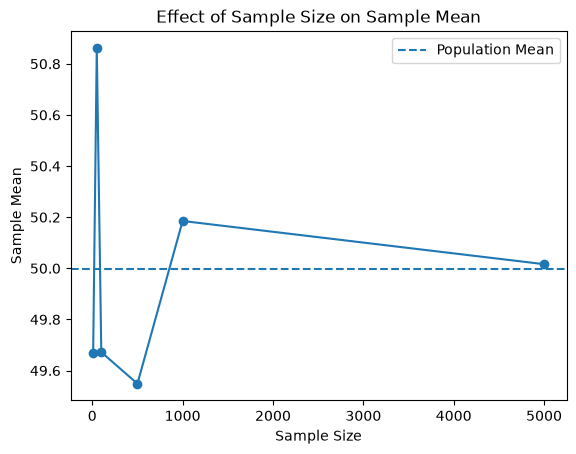

In [9]:
import numpy as np
import matplotlib.pyplot as plt

population = np.random.normal(
    loc=50,
    scale=10,
    size=10000
)

sample_sizes = [10, 50, 100, 500, 1000, 5000]
sample_means = []

for size in sample_sizes:
    sample = np.random.choice(
        population,
        size=size,
        replace=False
    )
    
    sample_means.append(np.mean(sample))

plt.plot(sample_sizes, sample_means, marker="o")

plt.axhline(
    np.mean(population),
    linestyle="--",
    label="Population Mean"
)

plt.xlabel("Sample Size")
plt.ylabel("Sample Mean")
plt.title("Effect of Sample Size on Sample Mean")
plt.legend()
plt.show()